In [213]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"D:\usha_phone\OneDrive\Desktop\Banglore_house_price_prediction\Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [214]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


Drop unwanted columns 


In [215]:
#drop duplicates
df = df.drop_duplicates()

df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [216]:
#Drop unwanted columns
cols = ["area_type","availability","society","balcony"]

df=df.drop(cols,axis=1)

In [217]:
#cleaning location columns

# 1. Remove leading and trailing spaces
df["location"]=df["location"].str.strip()
df["location"].value_counts()

#2. Handling nan values in location with top 2nd place --> Sarjapur  Road
df["location"] = df["location"].fillna("Sarjapur  Road")
df["location"]

#3. Grouping the location with less than 10 houses into others category
loc=df["location"].value_counts()
loc_less_than_10=loc[loc<=10]
df["location"]=df["location"].apply(lambda x: "others" if x in loc_less_than_10 else x)

In [218]:
df.isnull().sum()

location       0
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [219]:
#cleaning size column
#1. Handling nan values in size column
# df["size"].value_counts() # replace with 2bhk
df["size"]=df["size"].fillna("2 BHK")
#2. extract only the bhk number and remove unwanted characters 
df["size"]=df["size"].apply(lambda x : int(x.split()[0]))
df["size"].unique()
#3. rename size to bhk for better clarity 
df.rename(columns={"size":"bhk"},inplace=True)

In [220]:
# clean total square feet column
df["total_sqft"].unique()
def clean_total_sqft(sqft):
    try:
        l=sqft.split("-")
        if len(l)==2:
            return float(l[0]+float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None
df["total_sqft"]=df["total_sqft"].apply(clean_total_sqft)
#handling null values in total sqft
df["total_sqft"]=df["total_sqft"].fillna(df["total_sqft"].mean())

In [221]:
df.isnull().sum()

location       0
bhk            0
total_sqft     0
bath          73
price          0
dtype: int64

In [222]:
#cleaning bath column 
#Handling nan values in both 
med=df["bath"].median()
df["bath"]=df["bath"].fillna(med)
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [223]:
df.isnull().sum()

location      0
bhk           0
total_sqft    0
bath          0
price         0
dtype: int64

Handling outliers


In [224]:
#create a new column - price_per_sqft
#formula : price_per_sqft =price/total_sqft
df["price_per_sqft"]=(df["price"]*100000)/df["total_sqft"]

In [225]:
#Handling outliers in total square feet 

df.describe()
#observation : in total sqft column we have houses less than 300 sqft -- those are outliers
#in real time houses starts with minimum of 300 sqft

#formula :total_sqft/bhk>=300[--- it keeps all the realistic values]
df=df[df["total_sqft"]/df["bhk"]>=300]
df.describe()

,bhk,total_sqft,bath,price,price_per_sqft
count,12053.000000,12053.000000,12053.000000,12053.000000,12053.000000
mean,2.660582,1601.195512,2.572057,113.333833,6399.714189
std,0.988921,1271.910451,1.090977,154.689865,4316.174237
min,1.000000,300.000000,1.000000,8.440000,267.829813
25%,2.000000,1125.000000,2.000000,49.970000,4225.352113
50%,3.000000,1316.000000,2.000000,70.000000,5333.333333
75%,3.000000,1700.000000,3.000000,120.000000,7000.000000
max,16.000000,52272.000000,16.000000,3600.000000,176470.588235


All unrealistic total_sqft less than 300 got removed 

<Axes: xlabel='bhk'>

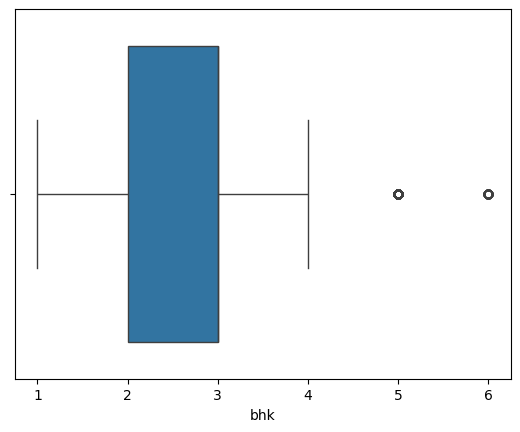

In [226]:
# Handling outliers in bhk column
df["bhk"].unique()
# sns.boxplot(x="bhk",data=df) # here outliers are more 
df=df[df["bhk"]<=6]
sns.boxplot(x="bhk",data=df)# outliers got reduced 


In [227]:
#handling outliers in bath column
df[df["bath"]>df["bhk"]+2][["bhk","bath"]]
#observation : here no of bath is suspiciously high compared to bhk number these are outliers
df=df[df["bath"]<df["bhk"]+2] # allowing these rows only --> removes unrealistic values where no of bath count is high than bhk

<Axes: xlabel='price_per_sqft'>

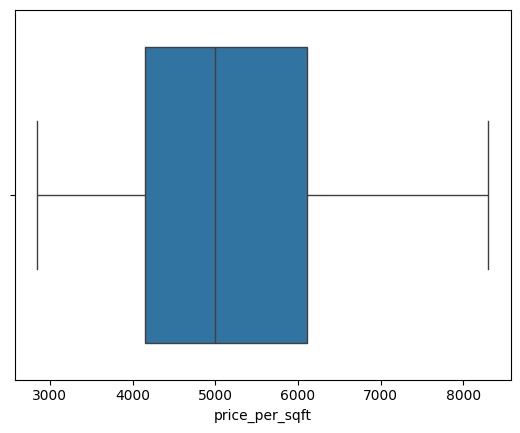

In [228]:
#handling outliers in price_per_sqft
# sns.boxplot(x="price_per_sqft",data=df)
#IQR method 
q1= df["price_per_sqft"].quantile(0.25)
q3= df["price_per_sqft"].quantile(0.75)
IQR =q3-q1
lower =q1-0.5*IQR
upper =q3+0.5*IQR
df=df[(df["price_per_sqft"]>=lower) &(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)


In [229]:
#remove price_per_sqft
df=df.drop("price_per_sqft",axis=1)

In [230]:
#reset index
df.reset_index(inplace=True)
df=df.drop("index",axis=1)
df.head()

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00


In [231]:
df

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9684,Rachenahalli,2,1050.0,2.0,52.71
9685,Bellandur,2,1262.0,2.0,47.00
9686,Green Glen Layout,3,1715.0,3.0,112.00
9687,Whitefield,5,3453.0,4.0,231.00


Text(0.5, 1.0, 'Total SQFT Vs Price')

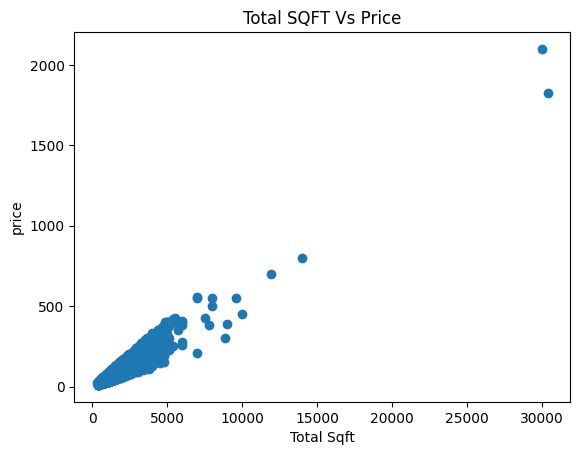

In [232]:
plt.scatter(df["total_sqft"],df["price"])
plt.xlabel("Total Sqft")
plt.ylabel("price")
plt.title("Total SQFT Vs Price")

<Axes: >

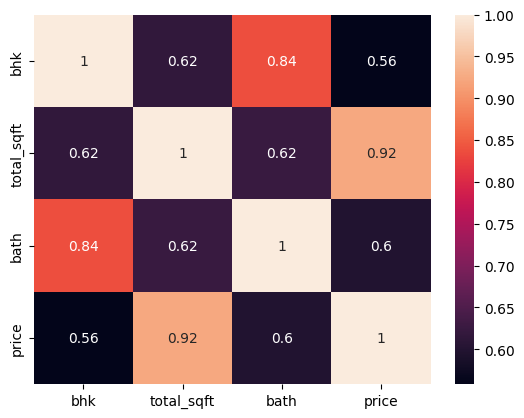

In [233]:
corr_data=df.iloc[:,1:].corr()
# corr_data
sns.heatmap(corr_data,annot=True)

In [234]:
# Avg price by location
data=df.groupby("location")["price"].mean().sort_values()
# plt.bar(data.index, data)
data

location
Kereguddadahalli                34.678571
Bommasandra Industrial Area     37.049583
Dommasandra                     37.837500
Anekal                          39.789286
Bisuvanahalli                   40.149500
                                  ...    
Old Airport Road               155.193750
Doddaballapur                  157.375000
Sector 7 HSR Layout            195.500000
2nd Stage Nagarbhavi           205.000000
Iblur Village                  224.200000
Name: price, Length: 233, dtype: float64

In [235]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [236]:
#Encoding location
encoder  = LabelEncoder()
df["encoded_loc"] = encoder.fit_transform(df["location"])

In [237]:
#divide into 2 different data 
X=df.drop(["location","price"],axis=1)
y=df.price

In [ ]:
#split 
Xtrain, Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)


In [239]:
#model training
LR = LinearRegression()
LR.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [240]:

ypred = LR.predict(Xtest)
ypred

array([ 59.65090271, 124.04503974,  58.58394348, ...,  27.78429307,
        46.43917246,  95.64331289], shape=(2907,))

In [241]:
print("Training Eff: ",LR.score(Xtrain,ytrain))
print("Testing Eff: ",LR.score(Xtest,ytest))
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.8732892846631006
Testing Eff:  0.7947579596551644
R2:  0.7947579596551644
MAE:  15.565032120639941


it is generalised model

decision tree 


In [242]:
DT=DecisionTreeRegressor()
DT.fit(Xtrain,ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [243]:
ypred=DT.predict(Xtest)
ypred

array([ 40.        , 140.        ,  45.73      , ...,  33.        ,
        41.22545455, 110.66666667], shape=(2907,))

In [244]:

print("Training Eff: ",DT.score(Xtrain,ytrain))
print("Testing Eff: ",DT.score(Xtest,ytest))
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.9892956996453934
Testing Eff:  0.7320712237630361
R2:  0.7320712237630361
MAE:  15.433536425933244


Decision tree is overfitting


In [245]:
#using pickle
#Model serialization-->Saving the trained model
#req:  it skips the continuous training process
import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(LR,file)

In [246]:

#encoder serialization
with open("label_encoder.pkl","wb") as file:
    pickle.dump(encoder,file)

In [247]:

#save the cleaned data
df.to_csv("cleaned_data.csv")

In [248]:
Xtrain

,bhk,total_sqft,bath,encoded_loc
1465,2,1030.000000,2.0,49
6112,3,1470.000000,2.0,74
2234,2,1300.000000,2.0,232
1744,2,1200.000000,2.0,39
8029,2,1339.000000,2.0,232
...,...,...,...,...
5734,2,1400.000000,2.0,232
5191,2,1027.000000,2.0,90
5390,2,1564.984242,2.0,105
860,2,1339.000000,2.0,232
